# **Esame di Calcolo Numerico**
- Data: **10/02/2026**
- Studentessa: **Sonia Auciello**


### Importazione delle librerie principali

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

### 1) Funzioni di supporto (Vandermonde, LU pivot totale, solve, nodi Chebyshev)

In [38]:
def vandermonde_matrix(x, deg):
    """
    Costruisce la matrice di Vandermonde (base potenze) con grado 'deg'.
    Colonne: 1, x, x^2, ..., x^deg
    """
    x = np.asarray(x, dtype=float)
    return x[:, None] ** np.arange(deg + 1)

def LU_pivot_totale(A):
    """
    Fattorizzazione PAQ = LU con Pivot Totale .
    Cerca il massimo assoluto nella sottomatrice U[k:,k:].
    """
    A = A.astype(float).copy()
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)
    P = np.eye(n)
    Q = np.eye(n)

    for k in range(n - 1):
        # 1) pivot massimo nella sottomatrice
        sub = np.abs(U[k:, k:])
        max_idx = np.argmax(sub)
        r_rel, c_rel = np.unravel_index(max_idx, sub.shape)
        r_curr = r_rel + k
        c_curr = c_rel + k

        # 2) scambio righe
        if r_curr != k:
            U[[k, r_curr], :] = U[[r_curr, k], :]
            P[[k, r_curr], :] = P[[r_curr, k], :]
            if k > 0:
                L[[k, r_curr], :k] = L[[r_curr, k], :k]

        # 3) scambio colonne
        if c_curr != k:
            U[:, [k, c_curr]] = U[:, [c_curr, k]]
            Q[:, [k, c_curr]] = Q[:, [c_curr, k]]

        # 4) eliminazione
        pivot = U[k, k]
        if abs(pivot) < 1e-14:
            print(f"Attenzione: Pivot nullo o quasi nullo allo step {k}")
        for i in range(k + 1, n):
            factor = U[i, k] / pivot
            L[i, k] = factor
            U[i, k:] -= factor * U[k, k:]

    return P, L, U, Q

def solve_LU_pivot_totale(P, L, U, Q, b):
    """
    Risolve Ax=b sapendo PAQ=LU:
      1) Ly = P b
      2) Uz = y
      3) x = Q z
    """
    Pb = np.dot(P, b)
    y = la.solve_triangular(L, Pb, lower=True)
    z = la.solve_triangular(U, y, lower=False)
    x = np.dot(Q, z)
    return x

def nodi_chebyshev(a, b, n):
    """
    Nodi di Chebyshev su [a,b]:
    c_k = (a+b)/2 + (b-a)/2 * cos((2k+1)pi/(2n)), k=0..n-1
    """
    k = np.arange(n)
    return (a + b)/2 + (b - a)/2 * np.cos(((2*k + 1) * np.pi) / (2*n))

 ### 2) Definizione problema, punti equidistanti (n=9, i=0..8)

In [39]:
f = lambda x: np.sin(np.pi * x) + 3*np.cos(np.pi * x)

a, b = -2.0, 2.0
n = 9                   # 9 punti => i = 0..8
deg = n - 1             # grado polinomio interpolante

xeval = np.linspace(a, b, 100)
feval = f(xeval)

# punti equidistanti
xeq = np.linspace(a, b, n)
yeq = f(xeq)

print("Punti equidistanti x_i:", xeq)
print("Ordinate y_i=f(x_i):", yeq)
print(f"Grado di p(x): {deg}")

Punti equidistanti x_i: [-2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]
Ordinate y_i=f(x_i): [ 3.  1. -3. -1.  3.  1. -3. -1.  3.]
Grado di p(x): 8


### 3) Polinomio p(x) (base monomiale) con LU pivot totale sulla Vandermonde V

In [40]:
Veq = vandermonde_matrix(xeq, deg)

P, L, U, Q = LU_pivot_totale(Veq)
coeffseq = solve_LU_pivot_totale(P, L, U, Q, yeq)

# Nota: np.polyval vuole coeff in ordine decrescente => invertiamo
peval = np.polyval(coeffseq[::-1], xeval)

print("Coefficienti p(x) in base potenze (c0..c8):")
print(coeffseq)

Coefficienti p(x) in base potenze (c0..c8):
[  3.           3.04761905 -14.7047619   -4.62222222  11.6
   1.77777778  -3.2         -0.2031746    0.3047619 ]


### 4) Plot: punti, f(x), p(x) su 100 punti in [-2,2]

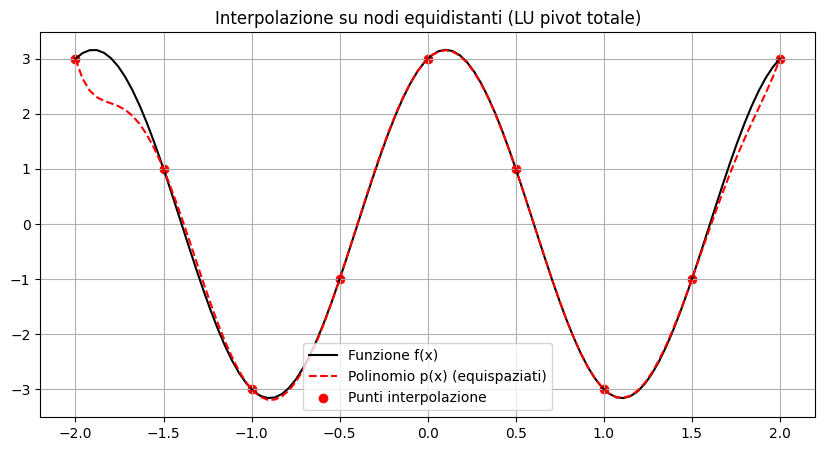

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(xeval, feval, 'k-', label='Funzione f(x)')
plt.plot(xeval, peval, 'r--', label='Polinomio p(x) (equispaziati)')
plt.scatter(xeq, yeq, color='red', label='Punti interpolazione')
plt.title('Interpolazione su nodi equidistanti (LU pivot totale)')
plt.grid(True)
plt.legend()
plt.show()

### 5) Nodi di Chebyshev 


In [42]:
xcheb = nodi_chebyshev(a, b, n)
ycheb = f(xcheb)

VC = vandermonde_matrix(xcheb, deg)

# LU pivot parziale 
lu, piv = la.lu_factor(VC)
coeffscheb = la.lu_solve((lu, piv), ycheb)

qeval = np.polyval(coeffscheb[::-1], xeval)

print("Nodi Chebyshev c_k:", xcheb)
print("Ordinate z_k=f(c_k):", ycheb)
print("Coefficienti q(x) (c0..c8):")
print(coeffscheb)

Nodi Chebyshev c_k: [ 1.96961551e+00  1.73205081e+00  1.28557522e+00  6.84040287e-01
  1.22464680e-16 -6.84040287e-01 -1.28557522e+00 -1.73205081e+00
 -1.96961551e+00]
Ordinate z_k=f(c_k): [ 2.89103188  1.25255794 -2.65305296 -0.80204215  3.         -2.47695991
 -1.08993494  2.7442276   3.0816535 ]
Coefficienti q(x) (c0..c8):
[  3.           2.81852305 -14.45143213  -4.05331814  10.96752049
   1.45321141  -2.83812609  -0.1543733    0.25030135]


 ### 6) Plot confronto: f(x), p(x), q(x)

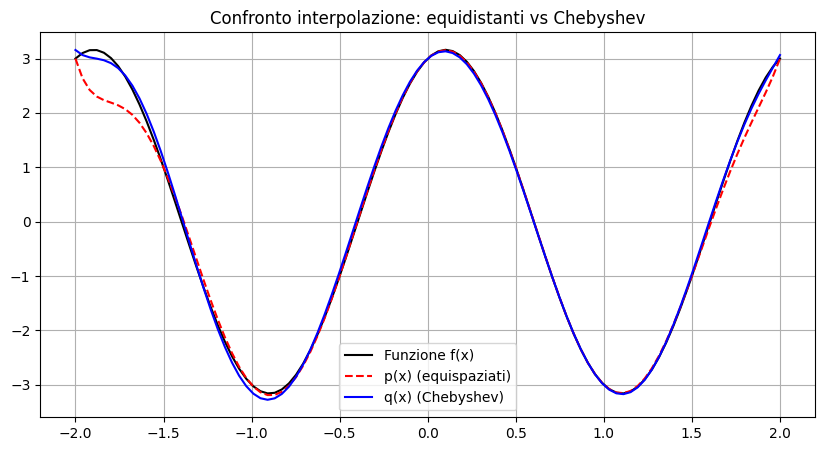

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(xeval, feval, 'k-', label='Funzione f(x)')
plt.plot(xeval, peval, 'r--', label='p(x) (equispaziati)')
plt.plot(xeval, qeval, 'b-', label='q(x) (Chebyshev)')
plt.title('Confronto interpolazione: equidistanti vs Chebyshev')
plt.grid(True)
plt.legend()
plt.show()

### 7) Considerazioni numeriche: condizionamento, fattori LU, residuo, errore interpolazione

In [44]:
# Condizionamento Vandermonde 
cond_Veq = np.linalg.cond(Veq, np.inf)
cond_VC  = np.linalg.cond(VC,  np.inf)

# Condizionamento dei fattori della LU pivot totale (P,L,U,Q)
cond_P = np.linalg.cond(P, np.inf)
cond_L = np.linalg.cond(L, np.inf)
cond_U = np.linalg.cond(U, np.inf)
cond_Q = np.linalg.cond(Q, np.inf)

# Residuo relativo 
res_eq = np.linalg.norm(Veq @ coeffseq - yeq, np.inf) / np.linalg.norm(yeq, np.inf)

# Errore di interpolazione (max su 100 punti)
err_eq   = np.max(np.abs(feval - peval))
err_cheb = np.max(np.abs(feval - qeval))

print("=== PARTE 3: Analisi Numerica ===")
print(f"Condizionamento V (Equidistanti): {cond_Veq:.2e}")
print(f"Condizionamento V (Chebyshev):   {cond_VC:.2e}")
print("\nCondizionamento fattori LU pivot totale (su Veq):")
print(f"cond(P) = {cond_P:.2e}  (atteso ~1)")
print(f"cond(L) = {cond_L:.2e}")
print(f"cond(U) = {cond_U:.2e}")
print(f"cond(Q) = {cond_Q:.2e}  (atteso ~1)")
print(f"\nResiduo relativo (Equidistante): {res_eq:.2e}")
print(f"Errore Max (Equidistante):       {err_eq:.2e}")
print(f"Errore Max (Chebyshev):          {err_cheb:.2e}")

=== PARTE 3: Analisi Numerica ===
Condizionamento V (Equidistanti): 1.16e+04
Condizionamento V (Chebyshev):   5.33e+03

Condizionamento fattori LU pivot totale (su Veq):
cond(P) = 1.00e+00  (atteso ~1)
cond(L) = 1.62e+01
cond(U) = 4.16e+03
cond(Q) = 1.00e+00  (atteso ~1)

Residuo relativo (Equidistante): 2.07e-15
Errore Max (Equidistante):       8.73e-01
Errore Max (Chebyshev):          1.58e-01


### 8) Autovalori e Autovettori di VC: D, W e tipo di numeri

In [45]:
D, W = np.linalg.eig(VC)

print("=== PARTE 4: Autovalori VC ===")
print("Autovalori D:")
print(D)

# Tipo di numeri:
# In generale gli autovalori possono essere complessi (anche se VC è reale).
# Qui lo vediamo direttamente stampando D: se compaiono parti immaginarie -> complessi.
abs_D = np.abs(D)
print("\nModuli |D|:")
print(abs_D)

=== PARTE 4: Autovalori VC ===
Autovalori D:
[188.64768827+0.j          12.64893555+0.j
 -11.72073596+0.j          -3.46247112+0.j
   3.19026608+0.j          -1.03751595+0.31353224j
  -1.03751595-0.31353224j   0.78331968+0.50414471j
   0.78331968-0.50414471j]

Moduli |D|:
[188.64768827  12.64893555  11.72073596   3.46247112   3.19026608
   1.08385507   1.08385507   0.93153187   0.93153187]


### 9) Polinomio con radici gli elementi di |D|

In [46]:
def costruisci_polinomio(x, radici):
    """
    P(x) = Π_i (x - r_i)
    """
    p = 1.0
    for r in radici:
        p *= (x - r)
    return p

def derivata_polinomio(x, radici):
    """
    P'(x) = Σ_i Π_{j!=i} (x - r_j)
    """
    res = 0.0
    nloc = len(radici)
    for i in range(nloc):
        prod_parziale = 1.0
        for j in range(nloc):
            if i != j:
                prod_parziale *= (x - radici[j])
        res += prod_parziale
    return res

radici_polinomio = abs_D
print("Radici del polinomio (|D|):")
print(radici_polinomio)

Radici del polinomio (|D|):
[188.64768827  12.64893555  11.72073596   3.46247112   3.19026608
   1.08385507   1.08385507   0.93153187   0.93153187]


### 10) Scelta di una radice adatta a Newton 
 Scelta pratica: la più grande tra le radici |D| (reale, lontana da 0).
 Per non perdere l’ordine quadratico, serve una radice semplice (P'(α)≠0).
 Nel polinomio prodotto su radici distinte, ogni radice è semplice.

In [47]:
target = np.max(radici_polinomio)
x0 = target * 1.1          # inizializzazione vicino
tol = 1e-10
max_it = 100

print(f"Radice target scelta: {target:.6f}")
print(f"x0 = {x0:.6f}")

Radice target scelta: 188.647688
x0 = 207.512457


### 11) Newton con 3 criteri di arresto 
 Criteri:
 1) Step assoluto: |x_{k+1}-x_k| < tol  
 2) Residuo: |P(x_{k+1})| < tol  
 3) Step relativo: |x_{k+1}-x_k| / (|x_{k+1}|+eps) < tol  

In [48]:
criteri = {
    1: "Step Assoluto",
    2: "Residuo",
    3: "Step Relativo"
}

print(f"\nAvvio Newton sul polinomio completo (grado {len(radici_polinomio)})")
print(f"{'Criterio':<15} | {'Iter':<5} | {'Soluzione':<14} | {'P(x)':<12}")
print("-" * 60)

for c_code, c_name in criteri.items():
    x_curr = x0
    it = 0
    stop = False

    while it < max_it and not stop:
        fx = costruisci_polinomio(x_curr, radici_polinomio)
        dfx = derivata_polinomio(x_curr, radici_polinomio)

        if abs(dfx) < 1e-16:
            print(f"{c_name:<15} | STOP  | derivata ~0")
            break

        step = fx / dfx
        x_new = x_curr - step

        # criteri arresto
        if c_code == 1:        # step assoluto
            err = abs(x_new - x_curr)
        elif c_code == 2:      # residuo
            err = abs(costruisci_polinomio(x_new, radici_polinomio))
        elif c_code == 3:      # step relativo
            err = abs(x_new - x_curr) / (abs(x_new) + 1e-16)

        if err < tol:
            stop = True

        x_curr = x_new
        it += 1

    val_finale = costruisci_polinomio(x_curr, radici_polinomio)
    print(f"{c_name:<15} | {it:<5} | {x_curr:<14.6f} | {val_finale:.2e}")


Avvio Newton sul polinomio completo (grado 9)
Criterio        | Iter  | Soluzione      | P(x)        
------------------------------------------------------------
Step Assoluto   | 7     | 188.647688     | 0.00e+00
Residuo         | 6     | 188.647688     | 0.00e+00
Step Relativo   | 7     | 188.647688     | 0.00e+00


### Considerazioni 
 1) Grado del polinomio:
  - Con i = 0..8 si hanno 9 nodi, quindi p(x) e q(x) sono di grado 8.

 2) Condizionamento delle matrici di Vandermonde:
    - In base monomiale, le Vandermonde tendono a essere mal condizionate,
      e il condizionamento cresce rapidamente con n.
   - Dai risultati, cond(Veq) risulta maggiore di cond(VC): usare nodi di Chebyshev
      migliora (riduce) il condizionamento rispetto ai nodi equidistanti.

3) Condizionamento dei fattori della LU con pivot totale:
    - P e Q sono matrici di permutazione ⇒ idealmente cond(P) ≈ 1 e cond(Q) ≈ 1.
    - I fattori L e U possono invece risultare più o meno mal condizionati:
      se cond(U) (o cond(L)) è grande, piccoli errori/arrotondamenti possono amplificarsi
      nella risoluzione dei sistemi triangolari.

 4) Residuo:
    - Il residuo relativo misura quanto bene i coefficienti soddisfano il sistema V*c=y.
   - È possibile avere residuo piccolo anche quando l’interpolazione è “cattiva”:
     infatti il sistema può essere risolto bene numericamente, ma il polinomio interpolante
     può oscillare (fenomeno di Runge) e approssimare male f(x) tra i nodi.

5) Errore di interpolazione (confronto p vs q):
   - L’errore max su una griglia di 100 punti è molto più grande per i nodi equidistanti
     rispetto ai nodi di Chebyshev (tipicamente: Chebyshev riduce le oscillazioni ai bordi).
   - Questo conferma che, a parità di grado, la scelta dei nodi è fondamentale.

6) Autovalori di VC:
   - Gli autovalori di una matrice reale possono essere reali o comparire in coppie complesse
     coniugate. Qui infatti compaiono valori complessi (in generale D è di tipo complesso).

7) Ordine di convergenza del metodo di Newton:
   - Newton ha ordine di convergenza QUADRATICO se la radice è semplice (P'(α) ≠ 0)
     e l’inizializzazione è sufficientemente vicina.
   - "Ordine quadratico" significa che, vicino alla soluzione, l’errore soddisfa circa:
       e_{k+1} ≈ C * (e_k)^2
     quindi il numero di cifre corrette cresce molto rapidamente.

8) Dipendenza dell’ordine dal criterio d’arresto:
   - L’ordine teorico del metodo NON cambia, ma il modo in cui interrompiamo le iterazioni
     può farci fermare prima di entrare pienamente nel regime quadratico (o troppo tardi).
   - Criteri diversi (step assoluto, step relativo, residuo) possono dare numeri di iterazioni
     diversi e “mascherare” sperimentalmente la fase quadratica se la tolleranza è troppo grande
     o se il criterio non è coerente con la scala del problema.